In [3]:
import os

base_dir = "artifacts"
figures_dir = os.path.join(base_dir, "figures")
os.makedirs(figures_dir, exist_ok=True)

print(f" Структура папок создана: {base_dir}/, {figures_dir}/")

 Структура папок создана: artifacts/, artifacts\figures/


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.utils import draw_bounding_boxes
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import random
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")

INPUT_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 10
EPOCHS = 10  
LR = 1e-3

 Using device: cuda


In [5]:

# Нормализация ImageNet (требуется для ResNet)
mean_imagenet = [0.485, 0.456, 0.406]
std_imagenet = [0.229, 0.224, 0.225]

# Базовый трансформ (для валидации, теста и C1)
base_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_imagenet, std=std_imagenet)
])

# Аугментации (для C2)
aug_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_imagenet, std=std_imagenet)
])

# Загрузка данных
train_dataset_full = torchvision.datasets.STL10(
    root='./data', split='train', download=True, transform=base_transform
)
test_dataset = torchvision.datasets.STL10(
    root='./data', split='test', download=True, transform=base_transform
)

# Разделение train/val (80/20)
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size
train_dataset, val_dataset = random_split(
    train_dataset_full, [train_size, val_size], 
    generator=torch.Generator().manual_seed(SEED)
)

# Датасет с аугментациями для C2
train_dataset_full_aug = torchvision.datasets.STL10(
    root='./data', split='train', download=True, transform=aug_transform
)
train_dataset_aug, _ = random_split(
    train_dataset_full_aug, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# Sanity Check
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}, Labels: {labels.shape}")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2.64G/2.64G [12:28<00:00, 3.53MB/s]


Train: 4000, Val: 1000, Test: 8000
Batch shape: torch.Size([64, 3, 224, 224]), Labels: torch.Size([64])


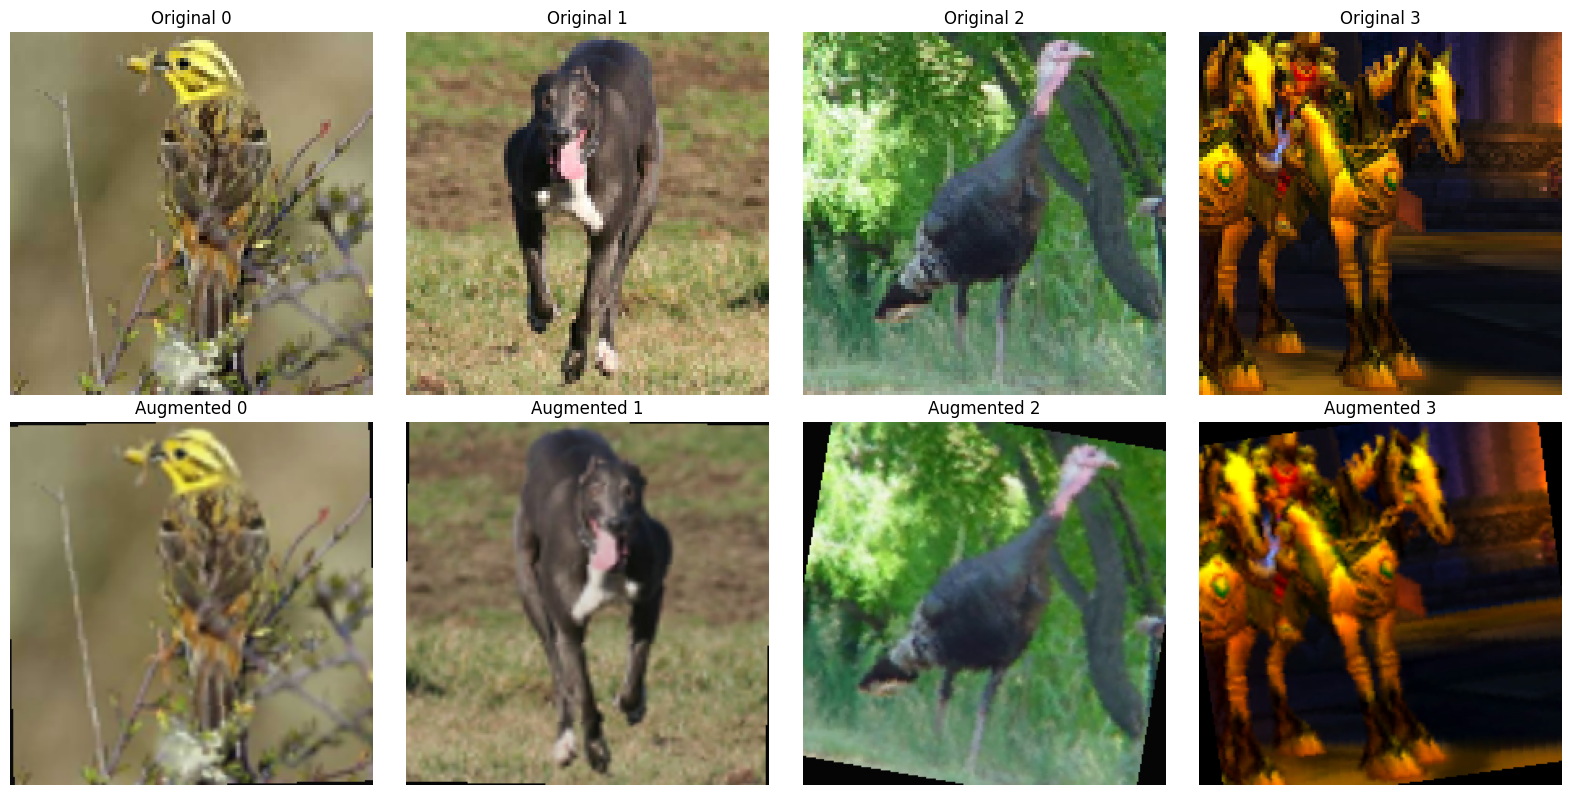

 Saved: artifacts/figures/augmentations_preview.png


In [7]:
def plot_augmentations():
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    # Оригинальные изображения
    orig_dataset = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=transforms.ToTensor())
    for i in range(4):
        img = orig_dataset[i][0].permute(1, 2, 0)
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        axes[0, i].set_title(f'Original {i}')
    
    # Аугментированные изображения
    aug_dataset = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=aug_transform)
    
    # Конвертируем mean и std в тензоры для правильного broadcasting
    mean_tensor = torch.tensor(mean_imagenet).view(3, 1, 1)
    std_tensor = torch.tensor(std_imagenet).view(3, 1, 1)
    
    for i in range(4):
        img = aug_dataset[i][0]  # [C, H, W] - уже нормализованный
        # Денормализация: img * std + mean
        img = img * std_tensor + mean_tensor
        img = torch.clamp(img, 0, 1)
        img = img.permute(1, 2, 0)  # [H, W, C] для imshow
        axes[1, i].imshow(img)
        axes[1, i].axis('off')
        axes[1, i].set_title(f'Augmented {i}')
    
    plt.tight_layout()
    plt.savefig('artifacts/figures/augmentations_preview.png', dpi=150)
    plt.show()
    print(" Saved: artifacts/figures/augmentations_preview.png")

plot_augmentations()

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten()
        )
        self.classifier = nn.Linear(256 * (INPUT_SIZE // 16) * (INPUT_SIZE // 16), num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
    return total_loss / len(loader), 100. * correct / len(loader.dataset)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
    return total_loss / len(loader), 100. * correct / len(loader.dataset)

In [10]:
results = []
criterion = nn.CrossEntropyLoss()
best_val_acc = 0
best_model_state = None
best_experiment = None
best_history = None

def run_experiment(exp_id, model, train_ld, val_ld, optimizer, epochs, notes):
    global best_val_acc, best_model_state, best_experiment, best_history
    
    model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    current_best = 0
    
    for epoch in range(epochs):
        t_loss, t_acc = train_epoch(model, train_ld, optimizer, criterion, device)
        v_loss, v_acc = evaluate(model, val_ld, criterion, device)
        
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        
        if v_acc > current_best:
            current_best = v_acc
    
    if current_best > best_val_acc:
        best_val_acc = current_best
        best_model_state = model.state_dict().copy()
        best_experiment = exp_id
        best_history = history.copy()
    
    return current_best, history

print(" Запуск экспериментов C1-C4...")

# C1: Simple CNN, No Aug
print("\n[C1] Simple CNN, No Augmentations")
model_c1 = SimpleCNN(NUM_CLASSES)
optimizer_c1 = optim.Adam(model_c1.parameters(), lr=LR)
acc_c1, hist_c1 = run_experiment('C1', model_c1, train_loader, val_loader, optimizer_c1, EPOCHS, 'Simple CNN, no aug')
results.append({'experiment_id': 'C1', 'task': 'classification', 'dataset': 'STL10', 'seed': SEED, 
                'model_summary': 'SimpleCNN', 'optimizer': 'Adam', 'lr': LR, 'epochs_trained': EPOCHS,
                'best_val_accuracy': acc_c1, 'test_accuracy': '', 'precision': '', 'recall': '', 'mean_iou': '', 'notes': 'Simple CNN, no aug'})
print(f"  Val Accuracy: {acc_c1:.2f}%")

# C2: Simple CNN, Aug
print("\n[C2] Simple CNN, With Augmentations")
model_c2 = SimpleCNN(NUM_CLASSES)
optimizer_c2 = optim.Adam(model_c2.parameters(), lr=LR)
acc_c2, hist_c2 = run_experiment('C2', model_c2, train_loader_aug, val_loader, optimizer_c2, EPOCHS, 'Simple CNN, with aug')
results.append({'experiment_id': 'C2', 'task': 'classification', 'dataset': 'STL10', 'seed': SEED,
                'model_summary': 'SimpleCNN', 'optimizer': 'Adam', 'lr': LR, 'epochs_trained': EPOCHS,
                'best_val_accuracy': acc_c2, 'test_accuracy': '', 'precision': '', 'recall': '', 'mean_iou': '', 'notes': 'Simple CNN, with aug'})
print(f"  Val Accuracy: {acc_c2:.2f}%")

# C3: ResNet18 Head Only
print("\n[C3] ResNet18 Head Only (Frozen)")
resnet_c3 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in resnet_c3.parameters():
    param.requires_grad = False
num_ftrs = resnet_c3.fc.in_features
resnet_c3.fc = nn.Linear(num_ftrs, NUM_CLASSES)
optimizer_c3 = optim.Adam(resnet_c3.fc.parameters(), lr=LR)
acc_c3, hist_c3 = run_experiment('C3', resnet_c3, train_loader, val_loader, optimizer_c3, EPOCHS, 'ResNet18 Frozen')
results.append({'experiment_id': 'C3', 'task': 'classification', 'dataset': 'STL10', 'seed': SEED,
                'model_summary': 'ResNet18-Frozen', 'optimizer': 'Adam', 'lr': LR, 'epochs_trained': EPOCHS,
                'best_val_accuracy': acc_c3, 'test_accuracy': '', 'precision': '', 'recall': '', 'mean_iou': '', 'notes': 'ResNet18 Frozen'})
print(f"  Val Accuracy: {acc_c3:.2f}%")

# C4: ResNet18 Fine-tune
print("\n[C4] ResNet18 Fine-tune (Layer4 + FC)")
resnet_c4 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in resnet_c4.parameters():
    param.requires_grad = False
for param in resnet_c4.layer4.parameters():
    param.requires_grad = True
resnet_c4.fc = nn.Linear(num_ftrs, NUM_CLASSES)
params_to_optimize = list(resnet_c4.layer4.parameters()) + list(resnet_c4.fc.parameters())
optimizer_c4 = optim.Adam(params_to_optimize, lr=LR)
acc_c4, hist_c4 = run_experiment('C4', resnet_c4, train_loader, val_loader, optimizer_c4, EPOCHS, 'ResNet18 Fine-tune')
results.append({'experiment_id': 'C4', 'task': 'classification', 'dataset': 'STL10', 'seed': SEED,
                'model_summary': 'ResNet18-FineTune', 'optimizer': 'Adam', 'lr': LR, 'epochs_trained': EPOCHS,
                'best_val_accuracy': acc_c4, 'test_accuracy': '', 'precision': '', 'recall': '', 'mean_iou': '', 'notes': 'ResNet18 Fine-tune'})
print(f"  Val Accuracy: {acc_c4:.2f}%")

print(f"\n Лучший эксперимент: {best_experiment} с Val Accuracy: {best_val_acc:.2f}%")

 Запуск экспериментов C1-C4...

[C1] Simple CNN, No Augmentations
  Val Accuracy: 52.20%

[C2] Simple CNN, With Augmentations
  Val Accuracy: 55.10%

[C3] ResNet18 Head Only (Frozen)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Степан/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:04<00:00, 11.6MB/s]


  Val Accuracy: 94.80%

[C4] ResNet18 Fine-tune (Layer4 + FC)
  Val Accuracy: 92.10%

 Лучший эксперимент: C3 с Val Accuracy: 94.80%


In [11]:
# Сохранение лучшей модели
torch.save(best_model_state, 'artifacts/best_classifier.pt')
print(" Saved: artifacts/best_classifier.pt")

# Сохранение конфига
config = {
    'dataset': 'STL10',
    'architecture': best_experiment,
    'input_size': INPUT_SIZE,
    'batch_size': BATCH_SIZE,
    'learning_rate': LR,
    'epochs': EPOCHS,
    'seed': SEED,
    'best_val_accuracy': best_val_acc,
    'transforms': {
        'base': 'Resize+Normalize',
        'aug': 'Resize+Flip+Rotate+ColorJitter+Normalize'
    }
}
with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print(" Saved: artifacts/best_classifier_config.json")

 Saved: artifacts/best_classifier.pt
 Saved: artifacts/best_classifier_config.json



 Final Test Accuracy: 94.34%


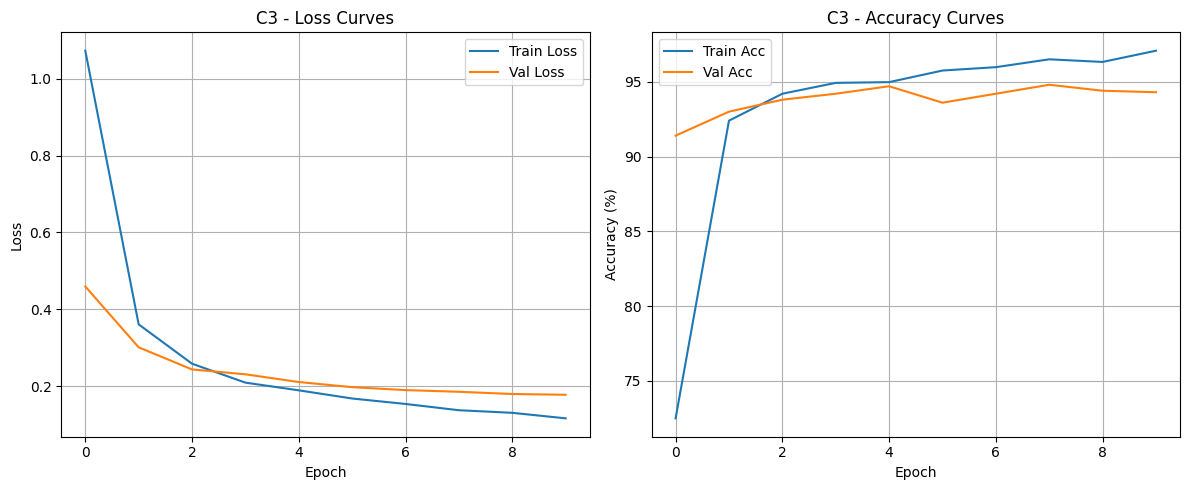

 Saved: artifacts/figures/classification_curves_best.png


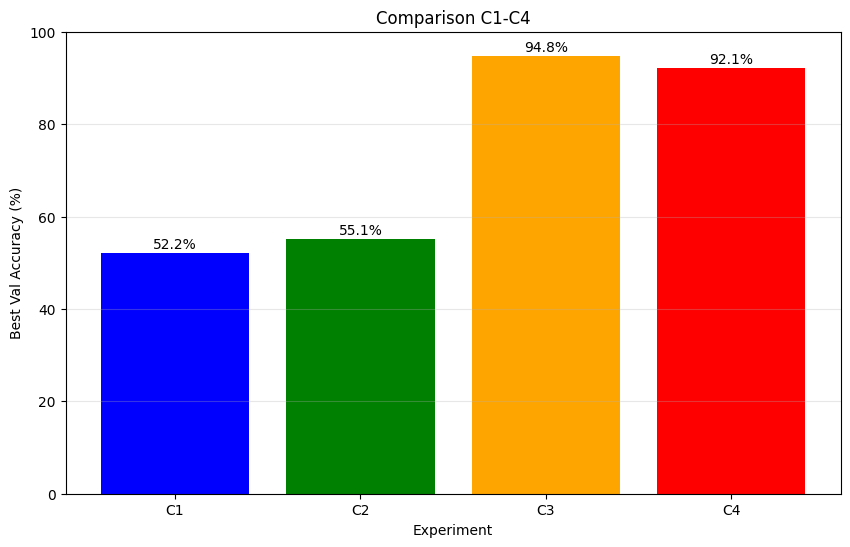

 Saved: artifacts/figures/classification_compare.png


In [12]:
# Загрузка лучшей модели для теста
if best_experiment in ['C1', 'C2']:
    best_model = SimpleCNN(NUM_CLASSES)
else:
    best_model = models.resnet18(weights=None)
    best_model.fc = nn.Linear(512, NUM_CLASSES)
    if best_experiment == 'C4':
        for param in best_model.layer4.parameters():
            param.requires_grad = True

best_model.load_state_dict(best_model_state)
best_model.to(device)
best_model.eval()

# Оценка на test
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"\n Final Test Accuracy: {test_acc:.2f}%")

# Обновление results с test accuracy
for r in results:
    if r['experiment_id'] == best_experiment:
        r['test_accuracy'] = test_acc

# 1. Curves для лучшего прогона
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_history['train_loss'], label='Train Loss')
plt.plot(best_history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'{best_experiment} - Loss Curves')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(best_history['train_acc'], label='Train Acc')
plt.plot(best_history['val_acc'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title(f'{best_experiment} - Accuracy Curves')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/classification_curves_best.png', dpi=150)
plt.show()
print(" Saved: artifacts/figures/classification_curves_best.png")

# 2. Сравнение C1-C4
exp_ids = ['C1', 'C2', 'C3', 'C4']
accuracies = [acc_c1, acc_c2, acc_c3, acc_c4]
colors = ['blue', 'green', 'orange', 'red']

plt.figure(figsize=(10, 6))
bars = plt.bar(exp_ids, accuracies, color=colors)
plt.xlabel('Experiment')
plt.ylabel('Best Val Accuracy (%)')
plt.title('Comparison C1-C4')
plt.ylim(0, 100)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{acc:.1f}%', ha='center')
plt.grid(axis='y', alpha=0.3)
plt.savefig('artifacts/figures/classification_compare.png', dpi=150)
plt.show()
print(" Saved: artifacts/figures/classification_compare.png")

In [17]:
print("\n Часть B: Detection Track (Pascal VOC)")

# Загрузка модели
model_det = fasterrcnn_resnet50_fpn(weights="DEFAULT")
model_det.to(device)
model_det.eval()

# VOC классы (0-й индекс - background, поэтому +1)
VOC_CLASSES = [
    "__background__", "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow", "diningtable", "dog", "horse",
    "motorbike", "person", "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

# Загрузка VOC
try:
    det_dataset = torchvision.datasets.VOCDetection(
        root='./data_voc', year='2007', image_set='test', download=True
    )
    print(f" VOC Dataset loaded: {len(det_dataset)} images")
except Exception as e:
    print(f" VOC download failed: {e}")
    print(" Using demo images for visualization only")
    det_dataset = None

def parse_voc_annotation(target):
    """Извлекает boxes и labels из XML аннотации VOCDetection"""
    boxes = []
    labels = []
    
    if 'annotation' in target:
        annotation = target['annotation']
        if 'object' in annotation:
            objects = annotation['object']
            if isinstance(objects, dict):
                objects = [objects]
            
            for obj in objects:
                # Bounding box
                bbox = obj['bndbox']
                xmin = float(bbox['xmin'])
                ymin = float(bbox['ymin'])
                xmax = float(bbox['xmax'])
                ymax = float(bbox['ymax'])
                boxes.append([xmin, ymin, xmax, ymax])
                
                # Class label
                class_name = obj['name']
                if class_name in VOC_CLASSES:
                    labels.append(VOC_CLASSES.index(class_name))
                else:
                    labels.append(0)  # background
    
    if len(boxes) > 0:
        return torch.tensor(boxes, dtype=torch.float32), torch.tensor(labels, dtype=torch.int64)
    else:
        return torch.empty((0, 4), dtype=torch.float32), torch.empty((0,), dtype=torch.int64)

def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    return intersection / union if union > 0 else 0

def evaluate_detection(pred_boxes, pred_labels, pred_scores, gt_boxes, gt_labels, iou_threshold=0.5):
    """
    Возвращает tp, fp, fn, mean_iou для одного изображения
    """
    tp, fp = 0, 0
    ious = []
    matched_gt = set()
    
    if len(pred_boxes) == 0:
        # Нет предсказаний — все GT это FN
        return 0, 0, len(gt_boxes), 0
    
    if len(gt_boxes) == 0:
        # Нет GT — все предсказания это FP
        return 0, len(pred_boxes), 0, 0
    
    for i in range(len(pred_boxes)):
        pb = pred_boxes[i].cpu().numpy()
        pl = pred_labels[i].item()
        best_iou = 0
        best_gt_idx = -1
        
        for j in range(len(gt_boxes)):
            if j in matched_gt:
                continue
            gb = gt_boxes[j].cpu().numpy()
            gl = gt_labels[j].item()
            
            if pl != gl:
                continue
                
            iou = calculate_iou(pb, gb)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = j
        
        if best_iou >= iou_threshold and best_gt_idx >= 0:
            tp += 1
            matched_gt.add(best_gt_idx)
            ious.append(best_iou)
        else:
            fp += 1
    
    fn = len(gt_boxes) - len(matched_gt)
    mean_iou = np.mean(ious) if ious else 0
    
    return tp, fp, fn, mean_iou 

# Режимы V1 и V2
thresholds = {'V1': 0.3, 'V2': 0.7}
det_results = []

if det_dataset:
    for mode, thresh in thresholds.items():
        print(f"\n[{mode}] Threshold: {thresh}")
        tp_total, fp_total, fn_total = 0, 0, 0
        ious_all = []
        vis_images = []
        
        for idx in range(min(10, len(det_dataset))):
            img, target = det_dataset[idx]
            img_tensor = transforms.ToTensor()(img).to(device)
            
            # Парсинг GT annotations
            gt_boxes, gt_labels = parse_voc_annotation(target)
            
            with torch.no_grad():
                pred = model_det([img_tensor])[0]
            
            boxes = pred['boxes'][pred['scores'] > thresh]
            labels = pred['labels'][pred['scores'] > thresh]
            scores = pred['scores'][pred['scores'] > thresh]
            
            # Оценка
            tp, fp, fn, miou = evaluate_detection(boxes, labels, scores, gt_boxes, gt_labels)
            tp_total += tp
            fp_total += fp
            fn_total += fn
            if miou > 0:
                ious_all.append(miou)
            
            # Визуализация
            if len(boxes) > 0:
                img_uint8 = (img_tensor * 255).to(dtype=torch.uint8)
                drawn = draw_bounding_boxes(img_uint8, boxes, colors="red", width=2)
                vis_images.append(drawn)
        
        # Итоговые метрики
        avg_precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) > 0 else 0
        avg_recall = tp_total / (tp_total + fn_total) if (tp_total + fn_total) > 0 else 0
        avg_iou = np.mean(ious_all) if ious_all else 0
        
        det_results.append({
            'experiment_id': mode, 'task': 'detection', 'dataset': 'PascalVOC', 'seed': SEED,
            'model_summary': 'FasterRCNN-ResNet50', 'optimizer': '', 'lr': '', 'epochs_trained': 0,
            'best_val_accuracy': '', 'test_accuracy': '', 'precision': avg_precision, 
            'recall': avg_recall, 'mean_iou': avg_iou, 'notes': f'Threshold={thresh}'
        })
        print(f"  TP: {tp_total}, FP: {fp_total}, FN: {fn_total}")
        print(f"  Precision: {avg_precision:.3f}, Recall: {avg_recall:.3f}, Mean IoU: {avg_iou:.3f}")
        
        # Сохранение визуализации
        if vis_images:
            fig, axes = plt.subplots(2, 3, figsize=(15, 10))
            for i, ax in enumerate(axes.flat):
                if i < len(vis_images):
                    ax.imshow(vis_images[i].permute(1, 2, 0).cpu())
                ax.axis('off')
            plt.suptitle(f'{mode} - Threshold {thresh}')
            plt.tight_layout()
            plt.savefig(f'artifacts/figures/detection_{mode.lower()}.png', dpi=150)
            plt.close()


 Часть B: Detection Track (Pascal VOC)
 VOC Dataset loaded: 4952 images

[V1] Threshold: 0.3
  TP: 1, FP: 88, FN: 31
  Precision: 0.011, Recall: 0.031, Mean IoU: 0.775

[V2] Threshold: 0.7
  TP: 1, FP: 55, FN: 31
  Precision: 0.018, Recall: 0.031, Mean IoU: 0.775


In [15]:
# Объединение всех результатов
all_results = results + det_results
df = pd.DataFrame(all_results)
df.to_csv('artifacts/runs.csv', index=False)
print("\n Saved: artifacts/runs.csv")
print(df.to_string())


 Saved: artifacts/runs.csv
  experiment_id            task    dataset  seed        model_summary optimizer     lr  epochs_trained best_val_accuracy test_accuracy precision   recall  mean_iou                 notes
0            C1  classification      STL10    42            SimpleCNN      Adam  0.001              10              52.2                                               Simple CNN, no aug
1            C2  classification      STL10    42            SimpleCNN      Adam  0.001              10              55.1                                             Simple CNN, with aug
2            C3  classification      STL10    42      ResNet18-Frozen      Adam  0.001              10              94.8       94.3375                                    ResNet18 Frozen
3            C4  classification      STL10    42    ResNet18-FineTune      Adam  0.001              10              92.1                                               ResNet18 Fine-tune
4            V1       detection  PascalVOC